### Aula 1 - Analisando dados com Pandas

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('salaries.csv', sep=',')

In [3]:
df.head()

# head é o cabeçalho. Se eu colocar um número dentro do parentes vai aparecer mais linhas. Ex: df.head(10) vai mostrar as 10 primeiras linhas.

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M


In [4]:
df.info()

# pra trazer as infos do dataframe, como tipo de dado, quantas linhas, colunas, valores nulos, etc.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [5]:
df.describe()

# traz as estatísticas descritivas das colunas numéricas do dataframe.

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [6]:
df.shape

# pra ver o tamanho do dataframe (linhas, colunas)

(133349, 11)

In [7]:
linhas, colunas = df.shape[0], df.shape[1]

# pq as linhas tao na posição 0 da lista e colunas tao na posição 1

print ('Linhas:', linhas, 'Colunas:', colunas)

Linhas: 133349 Colunas: 11


In [8]:
df.columns

# pra ver o nome das colunas do dataframe

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [9]:
renomear_colunas = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}

# aqui eu crio tipo um dicionário pra renomear as colunas do dataframe

df.rename(columns=renomear_colunas, inplace=True)

# aqui eu aplico a renomeação das colunas no dataframe com o método rename e o parâmetro inplace=True pra alterar o dataframe original


In [10]:
df.columns

Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'empresa', 'tamanho_empresa'],
      dtype='object')

In [11]:
# Qual é a frequencia de cada nível de experiência no dataset?

df['senioridade'].value_counts()

# o value_counts() traz a contagem de valores únicos em uma coluna específica do dataframe

senioridade
SE    77241
MI    40465
EN    12443
EX     3200
Name: count, dtype: int64

In [12]:
df['contrato'].value_counts()

contrato
FT    132563
CT       394
PT       376
FL        16
Name: count, dtype: int64

In [13]:
df['remoto'].value_counts()

remoto
0      105312
100     27718
50        319
Name: count, dtype: int64

In [14]:
df['tamanho_empresa'].value_counts()

tamanho_empresa
M    129561
L      3574
S       214
Name: count, dtype: int64

In [15]:
# renomeando as siglas da coluna senioridade

renomear_senioridade = {
    'SE': 'Senior',
    'MI': 'Pleno',
    'EN': 'Junior',
    'EX': 'Executivo'
}

df['senioridade'] = df['senioridade'].replace(renomear_senioridade)
df['senioridade'].value_counts()

# pode usar replace ou map pra fazer a substituição dos valores na coluna

senioridade
Senior       77241
Pleno        40465
Junior       12443
Executivo     3200
Name: count, dtype: int64

In [16]:
renomear_contrato = {
    'FT': 'integral',
    'PT': 'parcial',
    'CT': 'contrato',
    'FL': 'freelancer'
}

df['contrato'] = df['contrato'].replace(renomear_contrato)
df['contrato'].value_counts()

contrato
integral      132563
contrato         394
parcial          376
freelancer        16
Name: count, dtype: int64

In [17]:
renomear_tamanho_empresa = {
    'L': 'grande',
    'S': 'pequena',
    'M':	'media'

}

df['tamanho_empresa'] = df['tamanho_empresa'].replace(renomear_tamanho_empresa)
df['tamanho_empresa'].value_counts()

tamanho_empresa
media      129561
grande       3574
pequena       214
Name: count, dtype: int64

In [18]:
renomear_remoto = {
    0: 'presencial',
    100: 'remoto',
    50: 'hibrido'
}

df['remoto'] = df['remoto'].replace(renomear_remoto)
df['remoto'].value_counts()

remoto
presencial    105312
remoto         27718
hibrido          319
Name: count, dtype: int64

In [19]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025.0,Senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025.0,Pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025.0,Pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025.0,Junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


In [20]:
df.describe(include='object')

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Senior,integral,Data Scientist,USD,US,presencial,US,media
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [21]:
""" Com isso, já consegui responder algumas perguntas, como:

Qual o nível de experiência mais comum na base de dados?
Qual é o tipo de contrato mais frequente?
Qual o cargo mais frequente na amostra?
De qual país são a maioria dos profissionais da base?
Qual é o país onde mais empresas da amostra estão sediadas?
Qual o regime de trabalho mais comum?
Qual é o tamanho mais comum das empresas na amostra? """

' Com isso, já consegui responder algumas perguntas, como:\n\nQual o nível de experiência mais comum na base de dados?\nQual é o tipo de contrato mais frequente?\nQual o cargo mais frequente na amostra?\nDe qual país são a maioria dos profissionais da base?\nQual é o país onde mais empresas da amostra estão sediadas?\nQual o regime de trabalho mais comum?\nQual é o tamanho mais comum das empresas na amostra? '

### Aula 2 - Preparando e limpando dados

In [22]:
df.isnull()

# onde tem dado nulo ele marca como True

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [23]:
df.isnull().sum()

# soma a quantidade de valores nulos por coluna

ano                10
senioridade         0
contrato            0
cargo               0
salario             0
moeda               0
usd                 0
residencia          0
remoto              0
empresa             0
tamanho_empresa     0
dtype: int64

In [24]:
df['ano'].unique()

# Traz quais são os valores únicos dentro dessa coluna. "Nan" é valor nulo.

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [25]:
# Exibir quais as linhas que tem o valor nulo

df[df.isnull().any(axis=1)]


,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
5588,NaN,Senior,integral,Product Manager,184500,USD,184500,US,presencial,US,media
59692,NaN,Pleno,integral,Engineer,110000,USD,110000,DE,presencial,DE,media
59710,NaN,Junior,integral,Data Scientist,208800,USD,208800,US,presencial,US,media
59759,NaN,Senior,integral,Software Engineer,135000,USD,135000,US,presencial,US,media
59789,NaN,Senior,integral,Engineer,112000,USD,112000,US,presencial,US,media
131000,NaN,Senior,integral,Machine Learning Engineer,163800,USD,163800,US,presencial,US,media
131006,NaN,Senior,integral,Data Analytics Manager,204500,USD,204500,US,presencial,US,media
133054,NaN,Junior,integral,Data Scientist,40000,USD,40000,JP,remoto,MY,grande
133281,NaN,Pleno,integral,Machine Learning Engineer,180000,PLN,46597,PL,remoto,PL,grande
133317,NaN,Pleno,integral,Data Scientist,130000,USD,130000,US,hibrido,US,grande


In [26]:
""" O que fazer com essas linhas q tem dado nulo?
1. dá pra preencher com a média, mediana, moda"""

import numpy as np

# Aqui to criando um dataframe de exemplo com valores nulos na coluna salario
df_salarios = pd.DataFrame({
    'nome':['Ana', 'Bruno', 'Carlos', 'Daniele', 'Val'],
    'salario':[4000, np.nan, 5000, np.nan, 100000]
})

df_salarios['salarios'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))

# fillna é preencher os valores nulos com algum valor específico
# round(2) é pra arredondar pra 2 casas decimais

## Se tiver algum valor muito diferente na base, a média pode ser muito afetada. Sendo assim, não é a melhor opção. Nesse caso, a mediana seria mais indicada.

df_salarios['salarios_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())

df_salarios

,nome,salario,salarios,salarios_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,36333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,36333.33,5000.0
4,Val,100000.0,100000.00,100000.0


In [27]:
# 2. Dá pra repetir valores existentes

df_temperaturas = pd.DataFrame({
    'dia': ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'],
    'temperatura':[30, np.nan, np.nan, 28, 27]
})

df_temperaturas['preenchido_ffill'] = df_temperaturas['temperatura'].ffill()

# o ffill() preenche os valores nulos com o VALOR ANTERIOR, nesse caso pega da segunda-feira

df_temperaturas

,dia,temperatura,preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,30.0
2,Quarta,NaN,30.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [28]:

df_temperaturas = pd.DataFrame({
    'dia': ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta'],
    'temperatura':[30, np.nan, np.nan, 28, 27]
})

df_temperaturas['preenchido_ffill'] = df_temperaturas['temperatura'].bfill()

# o Bfill() preenche os valores nulos com o VALOR POSTERIOR,nesse caso pega da quinta-feira

df_temperaturas

,dia,temperatura,preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,28.0
2,Quarta,NaN,28.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [29]:
# 3. Dá pra preencher com um valor fixo, tipo "Não informado"

df_cidades = pd.DataFrame({
    'pessoa': ['Ana', 'Bruno', 'Carlos', 'Daniele', 'Val'],
    'cidade': ['São Paulo', np.nan, 'Curitiba', np.nan, 'Belém']
               
})

df_cidades['cidade_preenchida'] = df_cidades['cidade'].fillna('Não informado')

# fillna preenche os valores nulos com o valor que eu quiser, nesse caso "Não informado"

""" 
pra chamar função/operações matemáticas/métodos: parenteses 
pra criar um dicionário: chaves {}
pra acessar uma coluna específica: colchetes []
"""

df_cidades

,pessoa,cidade,cidade_preenchida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Daniele,NaN,Não informado
4,Val,Belém,Belém


In [30]:
# 4. Dá pra excluir as linhas com valores nulos. Como nesse caso são só 10 linhas, a exclusão não vai impactar tanto na análise dos dados.

df_limpo = df.dropna()

# dropna() exclui as linhas que tem valores nulos no dataframe original

In [31]:
df_limpo.isnull().sum()

# pra testar se não tem mais valores nulos no dataframe limpo

ano                0
senioridade        0
contrato           0
cargo              0
salario            0
moeda              0
usd                0
residencia         0
remoto             0
empresa            0
tamanho_empresa    0
dtype: int64

In [32]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025.0,Senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025.0,Pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025.0,Pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025.0,Junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


In [33]:
"""
A coluna ano tá classificada como float, por isso tem esse ".0"
Pra transformar em int, já que ano é um valor inteiro
"""

df_limpo = df_limpo.assign(ano=df_limpo['ano'].astype('Int64'))

# Aqui eu mudo o tipo de dado da coluna ano pra Int64 (inteiro)

df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025,Senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025,Pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025,Pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025,Junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


### Aula 3 - Visualizando os dados

In [34]:
df_limpo.head()

# pra ver as 5 primeiras linhas do dataframe limpo

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media
1,2025,Senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media
2,2025,Pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media
3,2025,Pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media
4,2025,Junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media


<Axes: title={'center': 'Distribuição de Senioridade'}, xlabel='senioridade'>

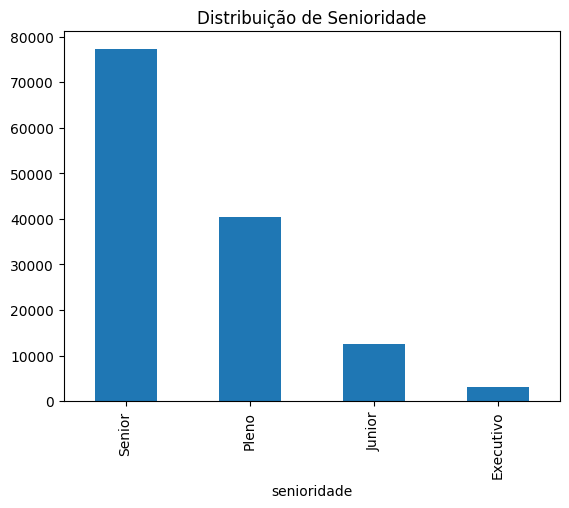

In [35]:
# criando um gráfico com a biblioteca Pandas

df_limpo['senioridade'].value_counts().plot(kind='bar', title='Distribuição de Senioridade')

# value_counts pra calcular a frequência
# kind é o tipo de gráfico, nesse caso de barras
# title é o título do gráfico

# Pra personalizar mais os gráficos, vamos utilizar as bibliotecas Matplotlib e Seaborn

In [36]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\josim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
import seaborn as sns

<Axes: xlabel='senioridade', ylabel='usd'>

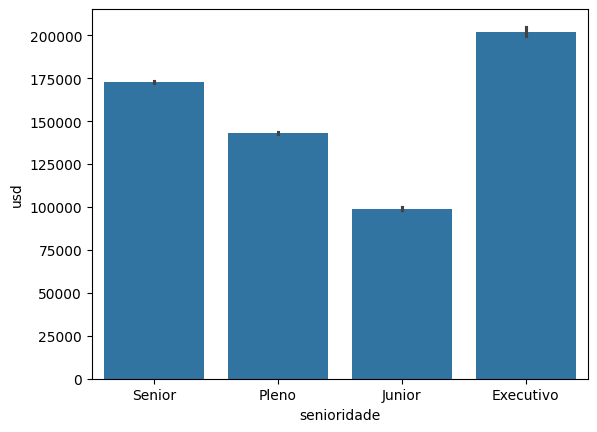

In [38]:
sns.barplot(data=df_limpo, x='senioridade', y='usd')

In [39]:
import matplotlib.pyplot as plt

# pyplot é um módulo especpifico dentro da biblioteca Matplotlib que contém várias funções para criar e personalizar gráficos.

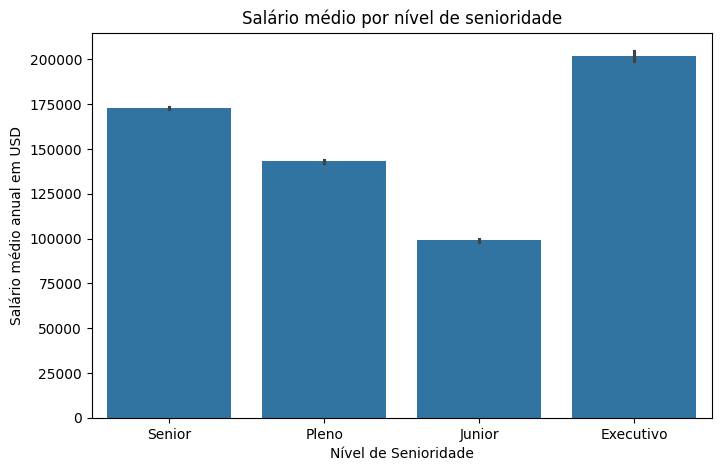

In [40]:
plt.figure(figsize=(8,5))

# figsize é pra determinar o tamanho da figura do gráfico

sns.barplot(data=df_limpo, x='senioridade', y='usd')

plt.title('Salário médio por nível de senioridade') # Título do gráfico
plt.xlabel('Nível de Senioridade') # rótulo (legenda) do eixo x
plt.ylabel('Salário médio anual em USD') # rótulo (legenda) do eixo y
plt.show() # pra apresentar o gráfico, sem texto nem código antes

In [41]:
# Pra facilitar a visualização do gráfico, o ideal é mostrar do maior pro menor valor

df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

# groupby pra agrupar os dados por uma coluna específica, nesse caso senioridade
# mean() pra calcular a média dos valores na coluna usd para cada grupo de senioridade

senioridade
Executivo    202027.667813
Senior       172850.838301
Pleno        143044.845979
Junior        99034.963267
Name: usd, dtype: float64

In [42]:
ordem= df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index

# .index pra juntar toda essa informação em uma única lista

ordem

Index(['Executivo', 'Senior', 'Pleno', 'Junior'], dtype='object', name='senioridade')

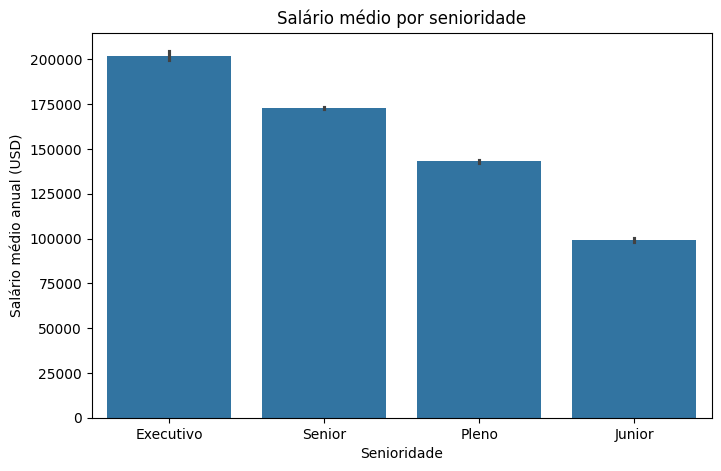

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', order=ordem)
plt.title("Salário médio por senioridade")
plt.xlabel("Senioridade")
plt.ylabel("Salário médio anual (USD)")
plt.show()

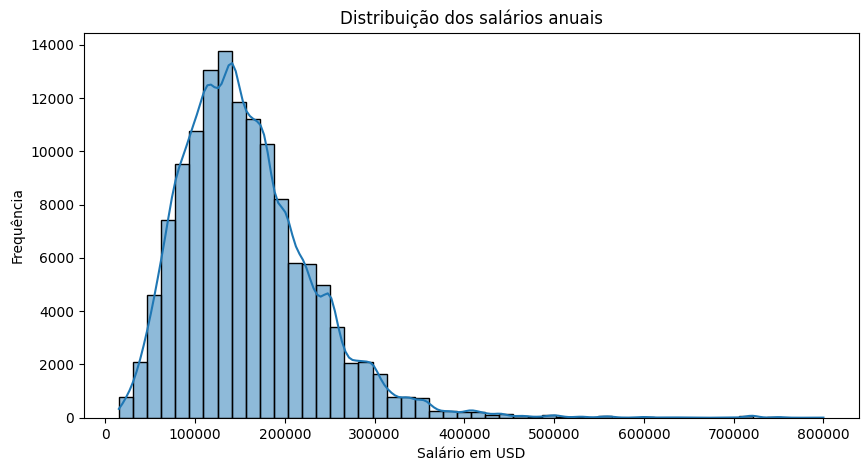

In [44]:
plt.figure(figsize=(10,5)) # primeiro é largura e segundo a altura
sns.histplot(df_limpo['usd'], bins=50, kde=True)
plt.title("Distribuição dos salários anuais")
plt.xlabel("Salário em USD")
plt.ylabel("Frequência")
plt.show()

# bins é o intervalo entre as barras do histograma
# Kde é uma estimativa de densidade que ajuda a visualizar a distribuição dos dados de forma mais suave. é a linhazinha.

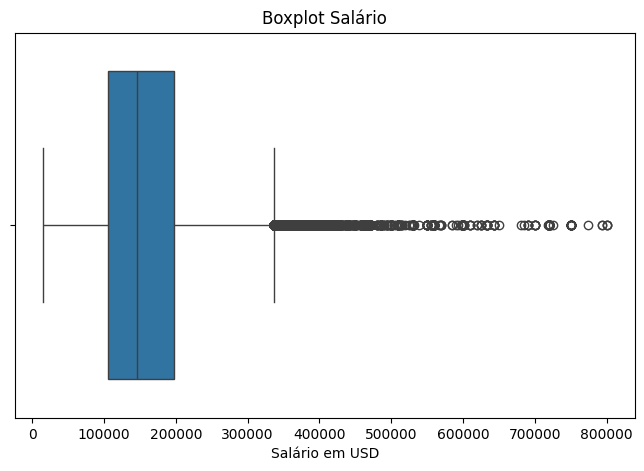

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_limpo['usd'])
plt.title("Boxplot Salário")
plt.xlabel("Salário em USD")
plt.show()

# boxplot é um gráfico de caixa que mostra a distribuição dos dados com base em cinco estatísticas resumidas: mínimo, primeiro quartil (Q1), mediana, terceiro quartil (Q3) e máximo.
# é um gráfico mais técnico, não é ideal pra apresentar em dashboards.
# Os pontinhos mais pro lado são outliers, ou seja, dados que são discrepantes, valores muito fora do padrão.

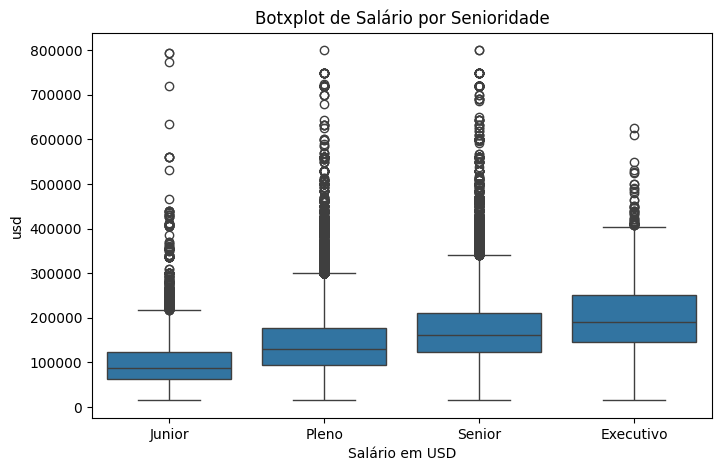

In [46]:
ordem_senioridade = ['Junior', 'Pleno', 'Senior', 'Executivo']

plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade)
plt.title("Botxplot de Salário por Senioridade")
plt.xlabel("Salário em USD")
plt.show()

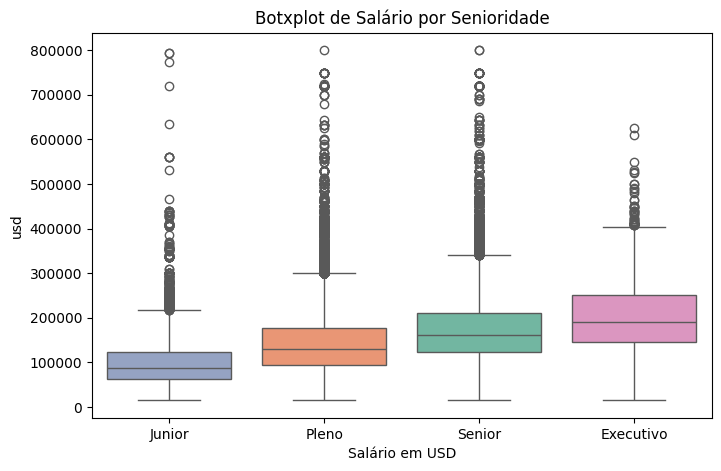

In [47]:
# Adicionando cores aos gráficos

ordem_senioridade = ['Junior', 'Pleno', 'Senior', 'Executivo']

plt.figure(figsize=(8,5))
sns.boxplot(x='senioridade', y='usd', data=df_limpo, order=ordem_senioridade, palette='Set2', hue='senioridade')
plt.title("Botxplot de Salário por Senioridade")
plt.xlabel("Salário em USD")
plt.show()

# pallet é o parâmetro que define a paleta de cores do gráfico
# Set2 é uma paleta pra cada categoria ter uma cor diferente
# hue é um parâmetro que serve pra categorizar os dados dentro do gráfico, tipo dividir por cores diferentes conforme uma coluna específica

In [48]:
!pip install plotly


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\josim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [49]:
# Criando gráficos interativos com Plotly
import plotly.express as px

senioridade_media_salario = df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False).reset_index()

fig = px.bar(senioridade_media_salario,
             x='senioridade',
             y='usd',
             title='Média Salarial por Senioridade',
             labels={'senioridade': 'Nível de Senioridade', 'usd': 'Média Salarial Anual (USD)'})

fig.show()

In [50]:
# Gráfico de pizza (pra melhor visualização, o ideal é ter poucas divisões

remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade'] # definindo os nomes das colunas

fig = px.pie(remoto_contagem,
             names='tipo_trabalho',
             values='quantidade',
             title='Proporção dos tipos de trabalho'

          )

fig.show()

In [51]:
# Transformando em um gráfico de rosquinha

remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade'] # definindo os nomes das colunas

fig = px.pie(remoto_contagem,
             names='tipo_trabalho',
             values='quantidade',
             title='Proporção dos tipos de trabalho',
             hole=0.5

          )

fig.update_traces(textinfo='percent+label') # pro rótulo aparecer junto com a porcentagem
fig.show()

In [54]:
pip install pycountry # biblioteca pra trabalhar com nomes de países

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#'

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\josim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pycountry # pra mudar a sigla dos países 

# Função para converter ISO-2 para ISO-3
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

# Criar nova coluna com código ISO-3
df_limpo['residencia_iso3'] = df_limpo['residencia'].apply(iso2_to_iso3)

# Calcular média salarial por país (ISO-3)
df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index()

# Gerar o mapa
fig = px.choropleth(media_ds_pais,
                    locations='residencia_iso3',
                    color='usd',
                    color_continuous_scale='rdylgn', # paleta específica
                    title='Salário médio de Cientista de Dados por país',
                    labels={'usd': 'Salário médio (USD)', 'residencia_iso3': 'País'})

fig.show()
     

In [56]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,Senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,Senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,Pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,Pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,Junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


In [57]:
df_limpo.to_csv('salaries_limpo.csv', index=False) #pra salvar o dataframe limpo em um arquivo CSV sem o índice  